In [7]:
import numpy as np
import finufft
import matplotlib.pyplot as pl
import random

pi = np.pi

## beta

In [27]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 40
Mc = 3e-2 * 2e30
f_max = 200
T_obs = 1e4
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)

In [28]:
tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff

In [29]:
bin_no = len(signal)
bins = np.arange(bin_no) - bin_no//2

f = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)

Maximum power at f = -520221.00


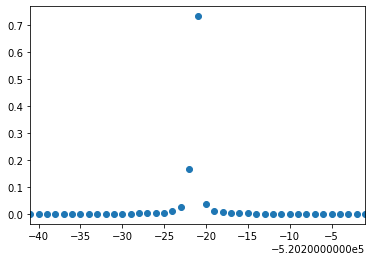

In [30]:
pl.plot(bins, abs(f/len(signal))**2, 'o')
max_bin = bins[np.argmax(abs(f)**2)]
pl.xlim(max_bin-20, max_bin+20)
found = bins[np.argmax(abs(f)**2)]
print('Maximum power at f = %.2f' % (found))

In [24]:
np.linspace(20, 40, 10, endpoint=False)

array([20., 22., 24., 26., 28., 30., 32., 34., 36., 38.])

In [42]:
f_max = 200
T_obs = 1e4
f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)
results = []

for i in range(10):
    #Constructing signal
    f0 = np.linspace(20, 40, 10, endpoint=False)[i]
    Mc = 3e-2 * 2e30
    beta = const*f0**(8/3)*Mc**(5/3)
    phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
    signal = 1*np.exp(1j*phi)
    
    # Analysis
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    bin_no = len(signal)
    bins = np.arange(bin_no) - bin_no//2
    f = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)
    
    results.append(np.max(np.abs(f/len(signal))**2))

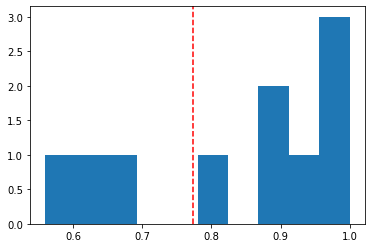

In [43]:
pl.hist(results)
pl.axvline(2.4306/pi, c='r', ls='--')